In [1]:
# hex2bin.py
# copyright@pifuyuini
# 仅供实验组成员 杨舒云、戴鹏辉、朱政鑫和马万成使用

def hex_to_binary_file(hex_file, binary_file):
    """
    将16进制的二进制文件转换为二进制文件
    """
    with open(hex_file, 'rb') as hex_f, open(binary_file, 'wb') as bin_f:
        hex_data = hex_f.read()  # 读取二进制文件
        # 将字节数据转换为16进制字符串，再转换为2进制表示
        bin_data = ''.join(format(byte, '08b') for byte in hex_data)  # 每个字节转换为8位的二进制
        bin_f.write(bin_data.encode())  # 将2进制数据写入文件

def calculate_ber(sent_binary_file, received_binary_file):
    """
    计算误码率
    """
    with open(sent_binary_file, 'rb') as sent_f, open(received_binary_file, 'rb') as recv_f:
        sent_bits = sent_f.read()
        recv_bits = recv_f.read()

        # 确保两个文件长度一致
        if len(sent_bits) != len(recv_bits):
            raise ValueError("发送端和接收端的二进制文件长度不一致，无法计算误码率。")

        # 计算误码率
        total_bits = len(sent_bits)  # 这里每个字符代表1位，因为我们已经处理为二进制表示
        error_bits = sum(c1 != c2 for c1, c2 in zip(sent_bits, recv_bits))

        ber = error_bits / total_bits
        return ber

# 文件路径
sent_hex_file = "transmitter_sift.bin"   # 发出端的16进制二进制文件路径
received_hex_file = "receiver_sift.bin"  # 接收端的16进制二进制文件路径

sent_binary_file = "transmitter_sift_binary.bin"  # 发出端的二进制文件路径
received_binary_file = "receiver_sift_binary.bin"  # 接收端的二进制文件路径

# 转换16进制文件为二进制文件
hex_to_binary_file(sent_hex_file, sent_binary_file)
hex_to_binary_file(received_hex_file, received_binary_file)

# 计算误码率
ber = calculate_ber(sent_binary_file, received_binary_file)
print(f"误码率为: {ber}")


误码率为: 0.012885736848499574


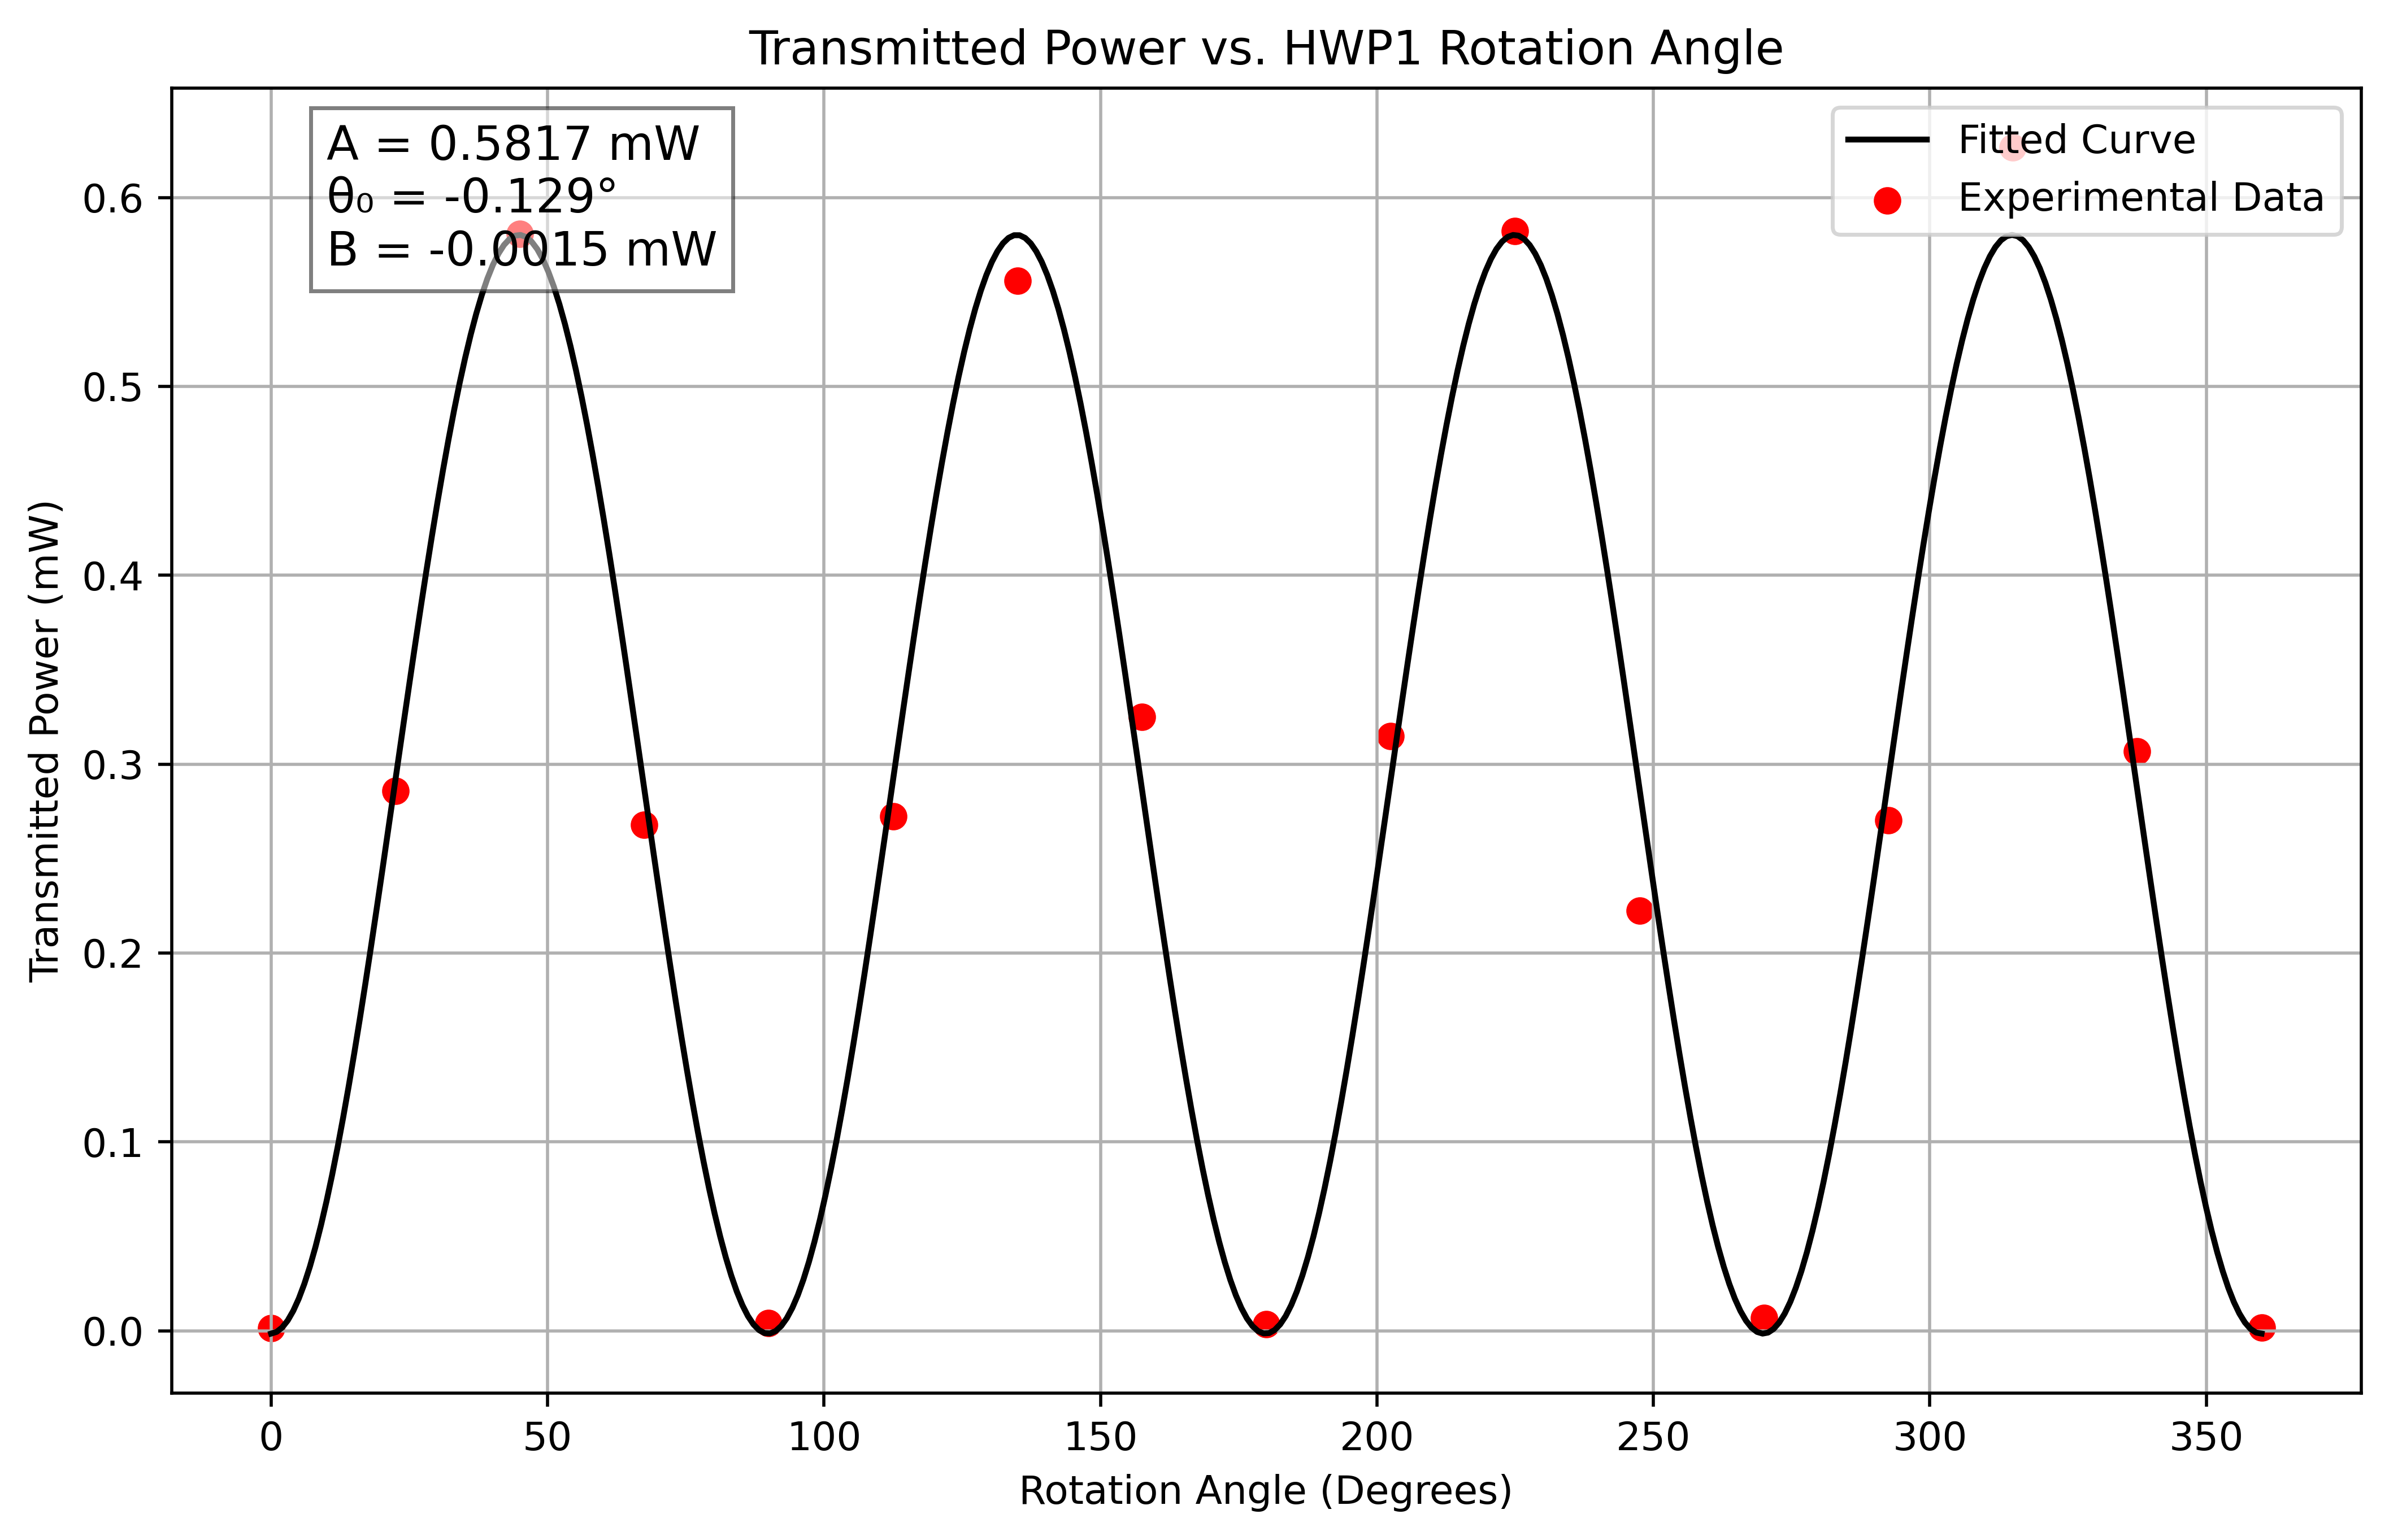

In [1]:
# 拟合代码
# copyright@pifuyuini

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
angles_deg = np.array([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5, 180,
                       202.5, 225, 247.5, 270, 292.5, 315, 337.5, 360])
powers_mw = np.array([0.00132129563, 0.285759054, 0.580764418, 0.267916832,
                      0.00392644935, 0.272270131, 0.555904257, 0.325087297,
                      0.0034673685, 0.314774831, 0.582103218, 0.222330989,
                      0.00683911647, 0.270395836, 0.626613865, 0.306902199,
                      0.00161435856])

# Convert angles to radians
angles_rad = np.deg2rad(angles_deg)

# Fitting function
def transmission_power(theta, A, theta0, B):
    return A * np.sin(2 * (theta - theta0))**2 + B

# Initial guesses for A, theta0, B
A_initial = (np.max(powers_mw) - np.min(powers_mw)) / 2
theta0_initial = 0
B_initial = np.min(powers_mw)

# Curve fitting
popt, _ = curve_fit(transmission_power, angles_rad, powers_mw,
                    p0=[A_initial, theta0_initial, B_initial])
A_fit, theta0_fit, B_fit = popt
theta0_fit_deg = np.rad2deg(theta0_fit)

# Generate fitted data
angles_fit = np.linspace(0, 2 * np.pi, 360)
powers_fit = transmission_power(angles_fit, *popt)

# Plotting
plt.figure(dpi=500, figsize=(10, 6))
plt.plot(np.rad2deg(angles_fit), powers_fit, label='Fitted Curve', color='black')
plt.scatter(angles_deg, powers_mw, label='Experimental Data', color='red')
plt.title('Transmitted Power vs. HWP1 Rotation Angle')
plt.xlabel('Rotation Angle (Degrees)')
plt.ylabel('Transmitted Power (mW)')
plt.legend()
plt.grid(True)
plt.text(10, np.max(powers_mw)*0.9, f'A = {A_fit:.4f} mW\n' +
         f'θ₀ = {theta0_fit_deg:.3f}°\n' +
         f'B = {B_fit:.4f} mW', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.show()
